In [1]:
import numpy as np
import pandas as pd

from utils import read_fit, read_ooc, read_xrr
from utils.profile_slab import AdaptiveOrientationProfile  # type: ignore
from utils.slab_builders import sio2, substrate, vacuum, surface


In [2]:
oocs = read_ooc("dft.csv", material="znpc")
data = read_xrr("reflectivity_data", material="znpc")

<Axes: xlabel='zed / $\\AA$', ylabel='Index of refraction'>

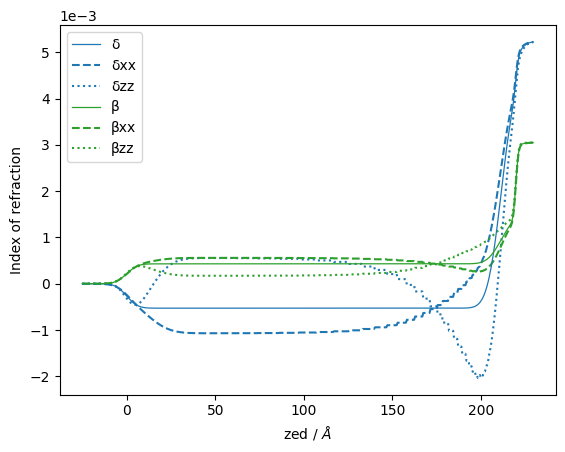

In [3]:
test_energy = 283.7

from utils.profile_slab import AdaptiveBookendedOrientationProfile

def model_bookend(
    energy: float,
    density: float = 1.61,
    num_slabs: int = 40,
    tau_si: float = 8,
    tau_vac: float = 10,
    alpha_bulk: float = np.pi / 2,
    alpha_si: float = 0,
    alpha_vac: float = 0,
    surface_roughness: float = 10,
):
    return (
        vacuum(energy)  # pyright: ignore[reportOperatorIssue]
        | AdaptiveBookendedOrientationProfile(
            oocs,
            energy=energy,
            total_thick=200,
            surface_roughness=surface_roughness,
            tau_si=tau_si,
            tau_vac=tau_vac,
            alpha_bulk=alpha_bulk,
            alpha_si=alpha_si,
            alpha_vac=alpha_vac,
            density=density,
            num_slabs=num_slabs,
            name=f"ZnPc_{energy:.1f}",
        )
        | sio2(energy)
        | substrate(energy)
    )

def model_dense(
    energy: float,
    total_thick: float = 200,
    surface_roughness: float = 10,
    density: float = 1.61,
    characteristic_thickness: float = 10,
    max_angle: float = np.pi / 2,
    initial_angle: float = 0,
    microslab_max_thickness: float = 1,
):
    from utils.profile_slab import OrientationProfile

    return (
        vacuum(test_energy)  # type: ignore
        | OrientationProfile(
            oocs,
            energy=energy,
            total_thick=total_thick,
            surface_roughness=surface_roughness,
            density=density,
            characteristic_thickness=characteristic_thickness,
            max_angle=max_angle,
            initial_angle=initial_angle,
            microslab_max_thickness=microslab_max_thickness,
            name=f"ZnPc_{energy:.1f}",
        )
        | sio2(test_energy)
        | substrate(test_energy)
    )


def model(
    energy: float,
    total_thick: float = 200,
    surface_roughness: float = 10,
    density: float = 1.61,
    characteristic_thickness: float = 10,
    max_angle: float = np.pi / 2,
    initial_angle: float = 0,
    num_slabs: int = 20,
):
    return (
        vacuum(energy)  # type: ignore
        | surface(energy, ooc=oocs, thick=11.5, rough=5)
        | AdaptiveOrientationProfile(
            oocs,
            energy=energy,
            total_thick=total_thick,
            surface_roughness=surface_roughness,
            density=density,
            characteristic_thickness=characteristic_thickness,
            max_angle=max_angle,
            initial_angle=initial_angle,
            name=f"ZnPc_{energy:.1f}",
            num_slabs=num_slabs,
        )
        | sio2(energy)
        | substrate(energy)
    )


model(test_energy, characteristic_thickness=40, num_slabs=50).plot()

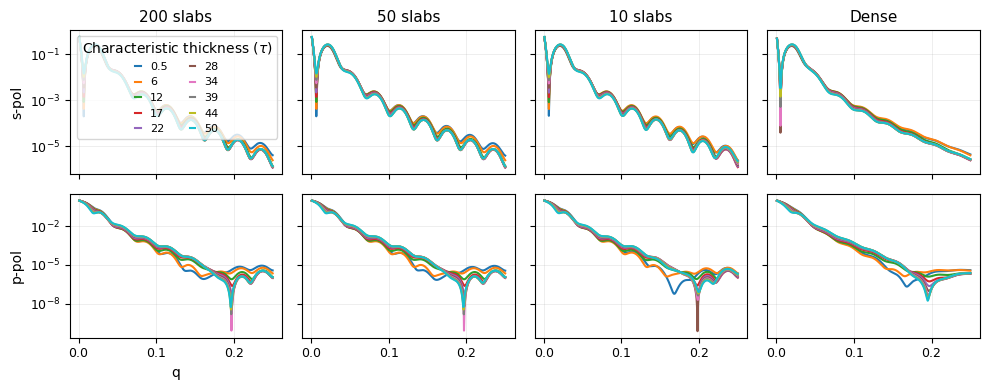

In [4]:
import matplotlib.pyplot as plt
import utils.helpers.plotting_helper as ph

ph.set_plotting_defaults()

characteristic_thicknesses = np.linspace(1, 100, num=10) ** 1 / 2
# round to no decimal places for all but the first one
characteristic_thicknesses = np.round(characteristic_thicknesses, 0)
characteristic_thicknesses[0] = 0.5

# use a color scheme with 10 unique colors
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(10, 4), sharex=True, sharey="row")
num_slabs_list = [200, 50, 10]
col_titles = ["200 slabs", "50 slabs", "10 slabs", "Dense"]

q = np.linspace(0.001, 0.25, 1000)

# Plot for regular models with variable num_slabs
for col, num_slabs in enumerate(num_slabs_list):
    ax1 = axes[0, col]
    ax2 = axes[1, col]
    for t, characteristic_thickness in enumerate(characteristic_thicknesses):
        mod = model(
            test_energy,
            characteristic_thickness=characteristic_thickness,
            num_slabs=num_slabs,
        )
        refl = mod.reflectivity(q)
        ax1.plot(q, refl[0], label=rf"{characteristic_thickness:1g}", color=colors[t])
        ax2.plot(q, refl[1], color=colors[t])
    ax1.set_yscale("log")
    ax2.set_yscale("log")
    ax1.set_title(col_titles[col])

# Plot for the dense model (no num_slabs parameter)
ax1 = axes[0, 3]
ax2 = axes[1, 3]
for t, characteristic_thickness in enumerate(characteristic_thicknesses):
    mod_dense = model_dense(
        test_energy, characteristic_thickness=characteristic_thickness
    )
    refl_dense = mod_dense.reflectivity(q)
    ax1.plot(q, refl_dense[0], label=rf"{characteristic_thickness:1g}", color=colors[t])
    ax2.plot(q, refl_dense[1], color=colors[t])
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.set_title(col_titles[3])

# Add legend to the leftmost top subplot only
axes[0, 0].legend(
    title=r"Characteristic thickness ($\tau$)",
    ncol=2,
    handlelength=0.5,
)

axes[1, 0].set_xlabel("q")
axes[0, 0].set_ylabel("s-pol")
axes[1, 0].set_ylabel("p-pol")

plt.tight_layout()
plt.show()


/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


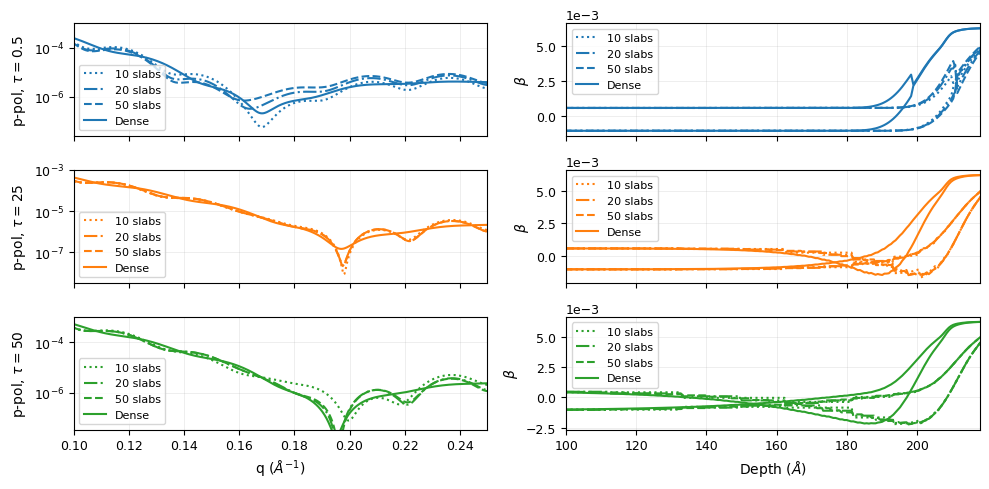

In [5]:
# Turn off tex in rext
plt.rcParams["text.usetex"] = False


characteristic_thicknesses = np.array([0.5, 25, 50])
num_slabs = np.array([10, 20, 50, None])

ls = [":", "-.", "--", "-"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 5), sharex="col")

for t, tau in enumerate(characteristic_thicknesses):
    for i, num in enumerate(num_slabs):
        mod = (
            model(test_energy, characteristic_thickness=tau, num_slabs=num)
            if num is not None
            else model_dense(
                test_energy,
                characteristic_thickness=tau,
            )
        )
        refl = mod.reflectivity(q)
        axes[t, 0].plot(
            q,
            refl[1],
            color=colors[t],
            ls=ls[i],
            label=f"{num} slabs" if num is not None else "Dense",
        )
        axes[t, 0].set_yscale("log")
        axes[t, 0].legend()
        axes[t, 0].set_ylim(None, 1e-3)
        axes[t, 0].set_xlim(0.1, 0.25)
        axes[t, 0].set_ylabel(f"p-pol, $\\tau = {tau:1g}$")
        z, profile = mod.sld_profile()
        mesh = mod.slabs()
        beta_xx = profile[:, 0]
        beta_zz = profile[:, 2]
        axes[t, 1].plot(
            z,
            beta_xx,
            color=colors[t],
            ls=ls[i],
            label=f"{num} slabs" if num is not None else "Dense",
        )
        axes[t, 1].plot(z, beta_zz, color=colors[t], ls=ls[i])
        axes[t, 1].set_xlim(2 * tau, z.max())
        # Use scientific notation for the y-axis
        axes[t, 1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
        axes[t, 1].set_ylabel(r"$\beta$")
        axes[t, 1].legend()
axes[2, 0].set_xlabel(r"q ($\AA^{-1}$)")
axes[2, 1].set_xlabel(r"Depth ($\AA$)")

plt.tight_layout()
plt.show()


(180.0, 205.0)

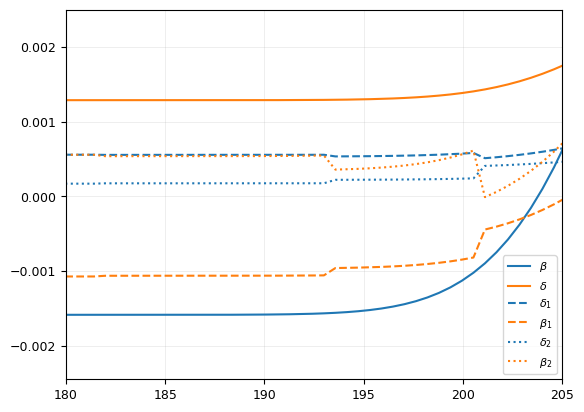

In [6]:
def model_plot(model, ax=None, show_roughness=True, shade_regions=False):
    from pyref.fitting.structure import birefringence_profile

    if ax is None:
        _, ax = plt.subplots()
    z, profile = birefringence_profile(
        model.slabs(), model.tensor(), z=None, step=not show_roughness
    )
    ls = ["-", "--", ":"]
    ax.plot(z, profile.sum(axis=1).real, label=r"$\beta$", ls=ls[0], c="C0")
    ax.plot(z, profile.sum(axis=1).imag, label=r"$\delta$", ls=ls[0], c="C1")
    for i in [1, 2]:
        ax.plot(z, profile[:, i].imag, label=rf"$\delta_{i}$", ls=ls[i], c="C0")
        ax.plot(z, profile[:, i].real, label=rf"$\beta_{i}$", ls=ls[i], c="C1")
        ax.legend()
    return ax


model_plot(
    model(test_energy, characteristic_thickness=8, num_slabs=10), show_roughness=True
)
plt.ylim(None, 0.0025)
plt.xlim(180, 205)

/tmp/ipykernel_1125308/575223507.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=2)


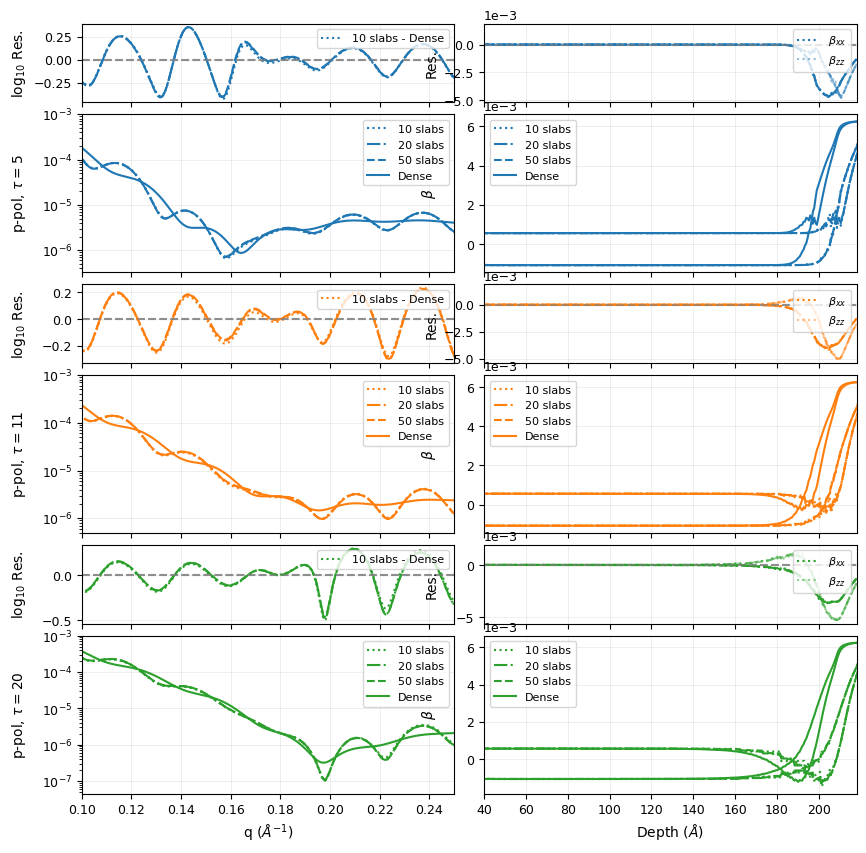

In [7]:
# Turn off tex in rext
plt.rcParams["text.usetex"] = False

characteristic_thicknesses = np.array([5, 11, 20])
num_slabs = np.array([10, 20, 50, None])

ls = [":", "-.", "--", "-"]

# New: add a row for residuals above each plot (so 2 rows for each thickness)
fig, axes = plt.subplots(
    nrows=3 * 2,
    ncols=2,
    figsize=(10, 10),
    sharex="col",
    gridspec_kw={"height_ratios": [1, 2] * 3, "hspace": 0.1, "wspace": 0.08},
)

# Store dense model output for residual calculation
dense_refls = []
dense_zs = []
dense_profiles = []

for t, tau in enumerate(characteristic_thicknesses):
    # Compute dense model once for current tau
    dense_mod = model_dense(
        test_energy,
        characteristic_thickness=tau,
    )
    dense_refl = dense_mod.reflectivity(q)
    dense_z, dense_profile = dense_mod.sld_profile()
    dense_beta_xx = dense_profile[:, 0]
    dense_beta_zz = dense_profile[:, 2]

    # Store for residual calculation per model
    dense_refls.append(dense_refl)
    dense_zs.append(dense_z)
    dense_profiles.append(dense_profile)

    for i, num in enumerate(num_slabs):
        mod = (
            model(test_energy, characteristic_thickness=tau, num_slabs=num)
            if num is not None
            else dense_mod
        )
        refl = mod.reflectivity(q)
        z, profile = mod.sld_profile()
        beta_xx = profile[:, 0]
        beta_zz = profile[:, 2]

        # Main axes for this tau
        refl_ax = axes[t * 2 + 1, 0]
        profile_ax = axes[t * 2 + 1, 1]
        # Residual axes for this tau
        refl_resid_ax = axes[t * 2, 0]
        profile_resid_ax = axes[t * 2, 1]

        # Plot reflectivity
        refl_ax.plot(
            q,
            refl[1],
            color=colors[t],
            ls=ls[i],
            label=f"{num} slabs" if num is not None else "Dense",
        )
        refl_ax.set_yscale("log")
        refl_ax.legend()
        refl_ax.set_ylim(None, 1e-3)
        refl_ax.set_xlim(0.1, 0.25)
        refl_ax.set_ylabel(f"p-pol, $\\tau = {tau:1g}$")

        # Plot SLD profiles (beta_xx, beta_zz)
        profile_ax.plot(
            z,
            beta_xx,
            color=colors[t],
            ls=ls[i],
            label=f"{num} slabs" if num is not None else "Dense",
        )
        profile_ax.plot(z, beta_zz, color=colors[t], ls=ls[i])
        profile_ax.set_xlim(2 * tau, z.max())
        profile_ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
        profile_ax.set_ylabel(r"$\beta$")
        profile_ax.legend()

        # For dense, skip residual since dense-dense is zero
        if num is None:
            # For dense, plot zero residual or skip entirely
            continue

        # Residuals for reflectivity (difference: model - dense)
        # Interpolate dense reflectivity if necessary
        refl_resid = np.log10(refl[1]) - np.log10(dense_refl[1])
        refl_resid_ax.plot(
            q, refl_resid, color=colors[t], ls=ls[i], label=f"{num} slabs - Dense"
        )
        refl_resid_ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
        refl_resid_ax.set_ylabel("log$_{10}$ Res.")
        if i == 0:
            refl_resid_ax.legend(fontsize=8, loc="upper right")
        refl_resid_ax.set_xlim(0.1, 0.25)

        # Residuals for SLD profile
        # Interpolate model profiles to dense grid for comparison
        z_dense = dense_z
        beta_xx_interp = np.interp(z_dense, z, beta_xx)
        beta_zz_interp = np.interp(z_dense, z, beta_zz)
        beta_xx_resid = beta_xx_interp - dense_beta_xx
        beta_zz_resid = beta_zz_interp - dense_beta_zz
        profile_resid_ax.plot(
            z_dense, beta_xx_resid, color=colors[t], ls=ls[i], label=r"$\beta_{xx}$"
        )
        profile_resid_ax.plot(
            z_dense,
            beta_zz_resid,
            color=colors[t],
            ls=ls[i],
            alpha=0.5,
            label=r"$\beta_{zz}$",
        )
        profile_resid_ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
        profile_resid_ax.set_xlim(2 * tau, z_dense.max())
        profile_resid_ax.set_ylabel("Res.")
        # Scientific notation for the y-axis
        profile_resid_ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
        if i == 0:
            profile_resid_ax.legend(fontsize=8, loc="upper right")

# Set shared x-labels
axes[-1, 0].set_xlabel(r"q ($\AA^{-1}$)")
axes[-1, 1].set_xlabel(r"Depth ($\AA$)")
fig.align_ylabels()
plt.tight_layout(h_pad=2)
plt.show()


In [8]:
model_bookend(283.7)

Structure(components=[Slab(Parameter(value=0.0, name='Vacuum_283.7_thick', vary=False, bounds=Interval(lb=0.0, ub=0.0), constraint=None), MaterialSLD('', Parameter(value=0.0, name='Vacuum_283.7_rho', vary=False, bounds=Interval(lb=0.0, ub=0.0), constraint=None),energy=250.0,  name='Vacuum_283.7'), Parameter(value=0.0, name='Vacuum_283.7_rough', vary=False, bounds=Interval(lb=0.0, ub=0.0), constraint=None), name='Vacuum_283.7',, <utils.profile_slab.AdaptiveBookendedOrientationProfile object at 0x703f2b31e540>, Slab(Parameter(value=8.22, name='Oxide_283.7_thick', vary=True, bounds=Interval(lb=0.0, ub=12.0), constraint=None), MaterialSLD('SiO2', Parameter(value=2.15, name='Oxide_283.7_rho', vary=False, bounds=Interval(lb=1.0, ub=2.3), constraint=None),energy=283.7,  name='Oxide_283.7'), Parameter(value=6.153, name='Oxide_283.7_rough', vary=True, bounds=Interval(lb=0.0, ub=8.0), constraint=None), name='Oxide_283.7',, Slab(Parameter(value=0.0, name='Substrate_283.7_thick', vary=False, bound

In [9]:
import pyref.fitting as fit
from pyref.fitting import Transform

from utils.slab_builders import select

objective = fit.AnisotropyObjective(
    fit.ReflectModel(model_bookend(283.7), energy=283.7),
    data["283.7"],
    logp_anisotropy_weight=0.5,
    transform=Transform("logY"),
)

select(objective, "Oxide").thick.setp(vary=False)
select(objective, "Oxide").rough.setp(vary=False)

select(objective, "ZnPc").total_thick.setp(vary=True, bounds=(150, 210))
select(objective, "ZnPc").surface_roughness.setp(vary=True, bounds=(0, 25))
select(objective, "ZnPc").density.setp(vary=True, bounds=(1, 2))
select(objective, "ZnPc").tau_si.setp(vary=False, bounds=(0, 10))
select(objective, "ZnPc").tau_vac.setp(vary=True, bounds=(0, 25))
select(objective, "ZnPc").alpha_bulk.setp(vary=True, bounds=(0, np.pi / 2))
select(objective, "ZnPc").alpha_si.setp(vary=True, bounds=(0, np.pi / 2))
select(objective, "ZnPc").alpha_vac.setp(vary=True, bounds=(0, np.pi / 2))

print(objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter: 'total_thick' , value=200          , bounds=[150.0, 210.0]>
<Parameter:   'density'   , value=1.61          , bounds=[1.0, 2.0]>
<Parameter:   'tau_vac'   , value=10          , bounds=[0.0, 25.0]>
<Parameter: 'alpha_bulk'  , value=1.5708          , bounds=[0.0, 1.5707963267948966]>
<Parameter:  'alpha_si'   , value=0          , bounds=[0.0, 1.5707963267948966]>
<Parameter:  'alpha_vac'  , value=0          , bounds=[0.0, 1.5707963267948966]>


In [10]:
from utils.helpers.fitting_helper import package_results
fitter = fit.CurveFitter(objective)
fitter.fit(method="differential_evolution", updating="deferred", workers=10)
package_results(fitter)

8.897657940287633: : 21it [00:46,  2.21s/it]


,value
name,
total_thick,192.79+/-0.24
density,1.64766356623205+/-0.00000000000007
tau_vac,25+/-4
alpha_bulk,0.573+/-0.012
alpha_si,0.000+/-0.030
alpha_vac,0.882+/-0.016
reduced_chi2,40.88916
aic,11869.856265
bic,11891.998421


(-12.0, 210.0)

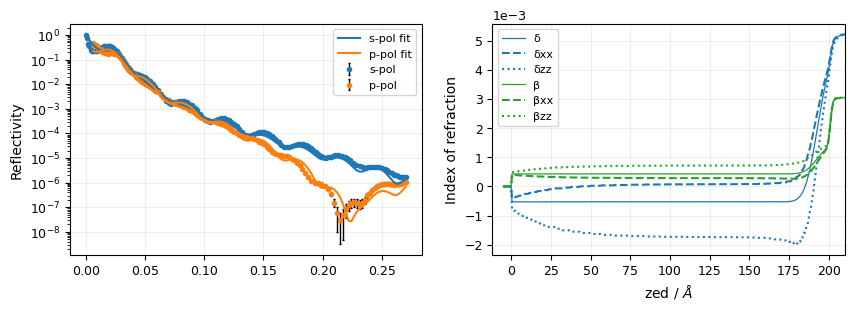

In [11]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10, 3))
fitter.objective.plot(ax=ax1, show_anisotropy=False)
fitter.objective.model.structure.plot(ax=ax2)
ax2.set_xlim(-12, 210)

In [36]:
import pyref.fitting as fit
from pyref.fitting import Transform

from utils.slab_builders import select


objective_list = [fit.AnisotropyObjective(
    fit.ReflectModel(model(283.7, characteristic_thickness=8, num_slabs=10), energy=283.7),
    data["283.7"],
    logp_anisotropy_weight=0.5,
    transform=Transform("logY"),
),
    fit.AnisotropyObjective(
        fit.ReflectModel(model(250, characteristic_thickness=8, num_slabs=10), energy=250),
        data["250.0"],
        logp_anisotropy_weight=0.5,
        transform=Transform("logY"),
    ),
]

def set_bounds(objective):
    select(objective, "Oxide").thick.setp(vary=False)
    select(objective, "Oxide").rough.setp(vary=False)

    select(objective, "Surface").rough.setp(vary=True, bounds=(0, 20))
    select(objective, "Surface").thick.setp(vary=True, bounds=(0, 80))
    select(objective, "Surface").sld.density.setp(vary=True, bounds=(1, 2.5))
    select(objective, "Surface").sld.rotation.setp(vary=True, bounds=(0, np.pi / 2))


    select(objective, "ZnPc").total_thick.setp(vary=True, bounds=(160, 210))
    select(objective, "ZnPc").surface_roughness.setp(vary=True, bounds=(0, 10))
    select(objective, "ZnPc").density.setp(vary=False, bounds=(1.5, 1.7))
    select(objective, "ZnPc").characteristic_thickness.setp(
        value=8, vary=False, bounds=(1, 20)
    )
    select(objective, "ZnPc").max_angle.setp(vary=True, bounds=(0, np.pi / 2))
    select(objective, "ZnPc").initial_angle.setp(vary=True, bounds=(0, np.pi / 2))

for objective in objective_list:
    set_bounds(objective)

select(objective_list[1], "Oxide").thick.setp(constraint=select(objective_list[0], "Oxide").thick)
select(objective_list[1], "Oxide").rough.setp(constraint=select(objective_list[0], "Oxide").rough)
select(objective_list[1], "Surface").thick.setp(constraint=select(objective_list[0], "Surface").thick)
select(objective_list[1], "Surface").rough.setp(constraint=select(objective_list[0], "Surface").rough)
select(objective_list[1], "Surface").sld.density.setp(constraint=select(objective_list[0], "Surface").sld.density)
select(objective_list[1], "Surface").sld.rotation.setp(constraint=select(objective_list[0], "Surface").sld.rotation)
select(objective_list[1], "ZnPc").total_thick.setp(constraint=select(objective_list[0], "ZnPc").total_thick)
select(objective_list[1], "ZnPc").surface_roughness.setp(constraint=select(objective_list[0], "ZnPc").surface_roughness)
select(objective_list[1], "ZnPc").density.setp(constraint=select(objective_list[0], "ZnPc").density)
select(objective_list[1], "ZnPc").characteristic_thickness.setp(constraint=select(objective_list[0], "ZnPc").characteristic_thickness)



global_objective = fit.GlobalObjective(objective_list)
print(global_objective.varying_parameters())
fitter = fit.CurveFitter(global_objective)

________________________________________________________________________________
Parameters:      None      
<Parameter:'Surface_283.7_thick', value=11.5          , bounds=[0.0, 80.0]>
<Parameter:'Surface_283.7_rough', value=5          , bounds=[0.0, 20.0]>
<Parameter:'Surface_283.7_density', value=1          , bounds=[1.0, 2.5]>
<Parameter:'Surface_283.7_rotation', value=0.8          , bounds=[0.0, 1.5707963267948966]>
<Parameter: 'total_thick' , value=200          , bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=10          , bounds=[0.0, 10.0]>
<Parameter:  'max_angle'  , value=1.5708          , bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=0          , bounds=[0.0, 1.5707963267948966]>
<Parameter:  'max_angle'  , value=1.5708          , bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=0          , bounds=[0.0, 1.5707963267948966]>


In [37]:
from time import perf_counter

start_time = perf_counter()
fitter.fit(method="differential_evolution", updating="deferred", workers=10)
elapsed_time = perf_counter() - start_time
print(f"Fitting took {elapsed_time:.2f} seconds")

36.70295097200021: : 31it [00:53,  1.73s/it] 


Fitting took 53.95 seconds


________________________________________________________________________________
Parameters:      None      
<Parameter:'Surface_283.7_thick', value=40.9167 +/- 0.572, bounds=[0.0, 80.0]>
<Parameter:'Surface_283.7_rough', value=6.45853 +/- 0.116, bounds=[0.0, 20.0]>
<Parameter:'Surface_283.7_density', value=1.36467 +/- 0.0145, bounds=[1.0, 2.5]>
<Parameter:'Surface_283.7_rotation', value=0.725894 +/- 0.00855, bounds=[0.0, 1.5707963267948966]>
<Parameter: 'total_thick' , value=161.475 +/- 0.558, bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=10 +/- 0.495, bounds=[0.0, 10.0]>
<Parameter:  'max_angle'  , value=0.468761 +/- 0.0376, bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=0 +/- 0.0351, bounds=[0.0, 1.5707963267948966]>
<Parameter:  'max_angle'  , value=0 +/- 9.56e+05, bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=9.86165e-07 +/- 1.04e+06, bounds=[0.0, 1.5707963267948966]>


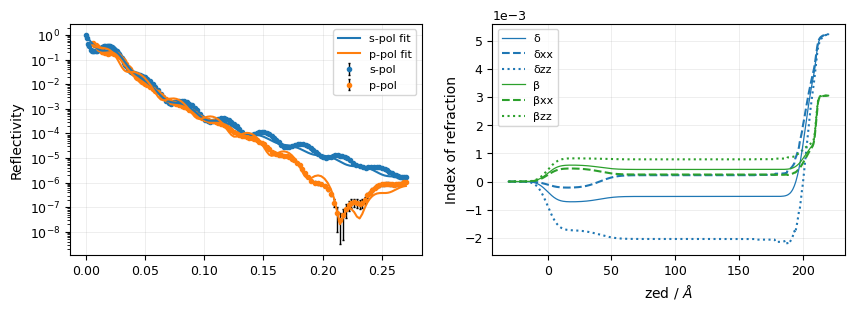

In [38]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10, 3))
fitter.objective.objectives[0].plot(ax=ax1, show_anisotropy=False)
fitter.objective.objectives[0].model.structure.plot(ax=ax2)
print(fitter.objective.varying_parameters())

In [42]:
import pandas as pd
from uncertainties import ufloat
from utils.helpers.fitting_helper import aic, bic, reduced_chi2

def save_fit_results_to_csv(fitter, filename="profile_fit_v3_initial.csv"):
    """
    Save fit results (parameters and statistics) from a fitter object to a CSV file.

    Parameters
    ----------
    fitter : CurveFitter or similar
        Fitter object containing the fit results.
    filename : str
        Name of the output CSV file.
    """
    params = fitter.objective.varying_parameters()
    table_rows = []
    for p in params:
        row = {
            "parameter": p.name,
            "ufloat": ufloat(p.value, p.stderr if p.stderr is not None else 0),
            "value": p.value,
            "stderr": p.stderr,
        }
        table_rows.append(row)

    # Add fit statistics at the bottom
    fit_stats = {
        "reduced_chi2": reduced_chi2(fitter.objective),
        "bic": bic(fitter.objective),
        "aic": aic(fitter.objective),
    }
    for key in fit_stats:
        table_rows.append({
            "parameter": key,
            "ufloat": fit_stats[key],
            "value": fit_stats[key],
            "stderr": None,
        })

    df = pd.DataFrame(table_rows)
    df.to_csv(filename, index=False)

# Usage
save_fit_results_to_csv(fitter, filename="profile_fit_v5_initial.csv")

/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/refnx/analysis/curvefitter.py:405: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  init_walkers = rng.multivariate_normal(
100%|██████████| 100/100 [01:10<00:00,  1.42it/s]


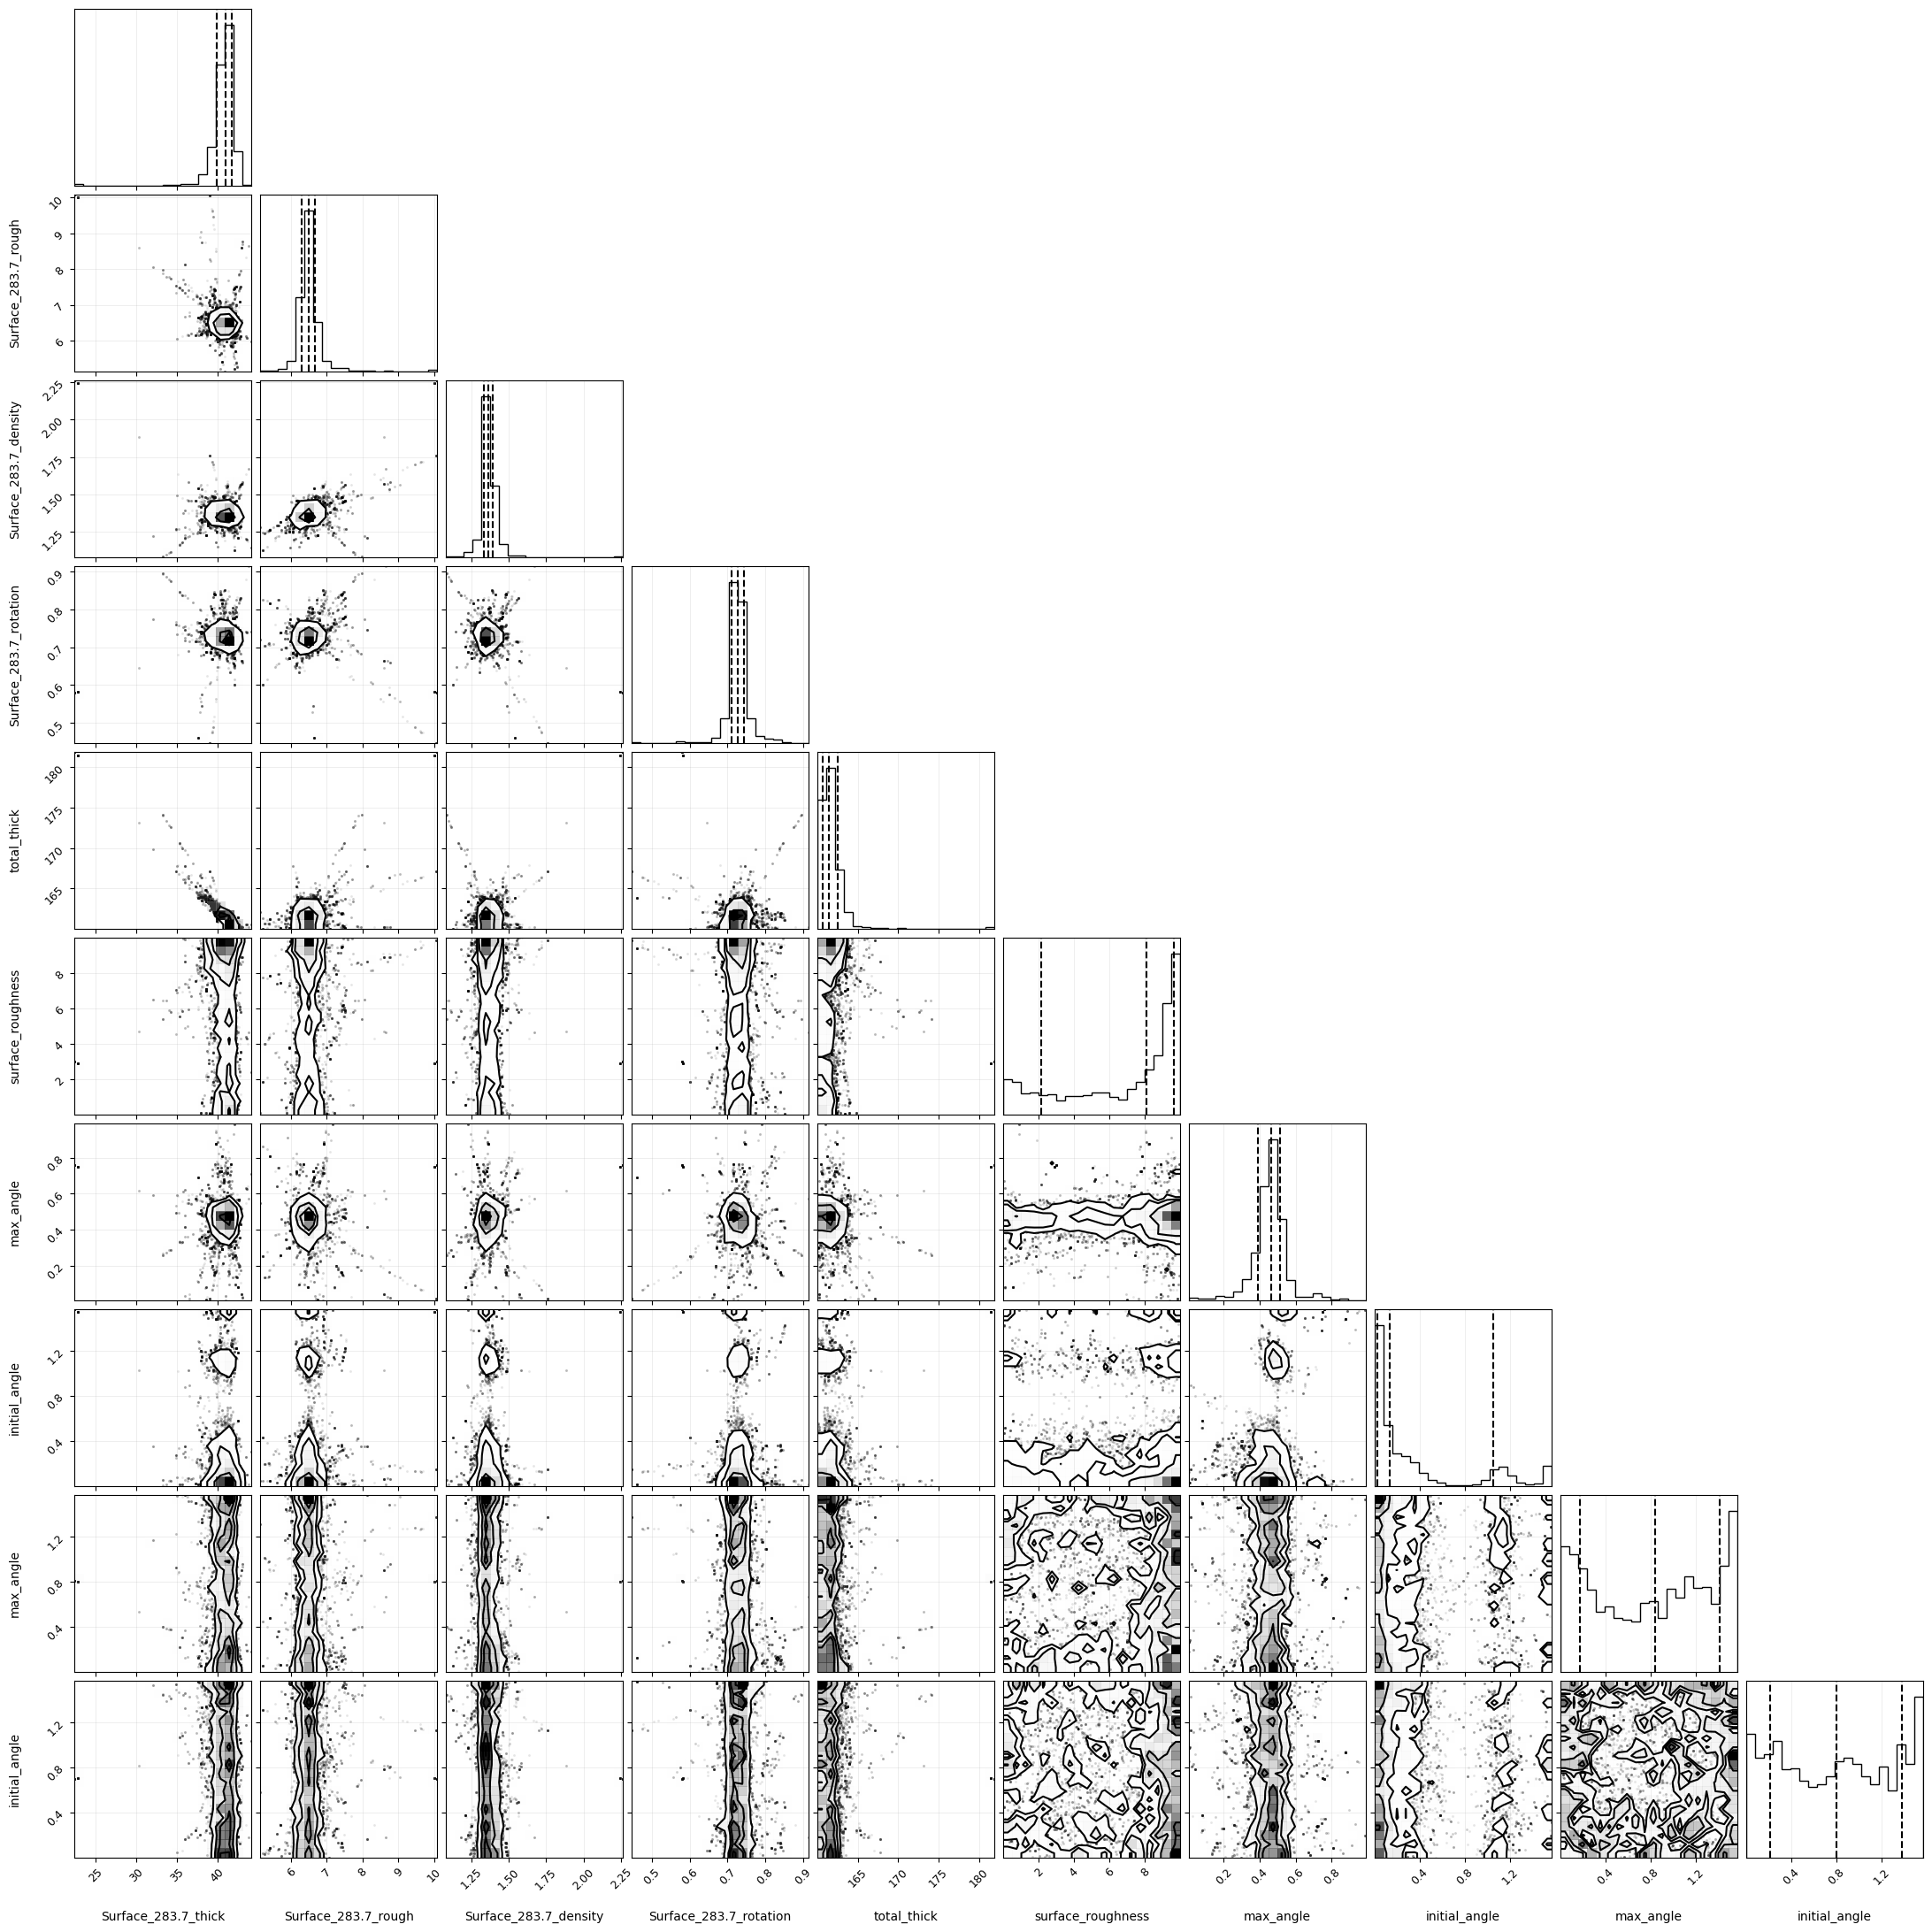

In [43]:
second_fitter = fit.CurveFitter(fitter.objective, walkers_per_param=20)
second_fitter.initialise()
samples = second_fitter.sample(100, skip_check=True)
second_fitter.objective.corner()
plt.show()

________________________________________________________________________________
Parameters:      None      
<Parameter:'Surface_283.7_thick', value=40.9981 +/- 0.949, bounds=[0.0, 80.0]>
<Parameter:'Surface_283.7_rough', value=6.4941 +/- 0.193, bounds=[0.0, 20.0]>
<Parameter:'Surface_283.7_density', value=1.36548 +/- 0.0301, bounds=[1.0, 2.5]>
<Parameter:'Surface_283.7_rotation', value=0.72729 +/- 0.0166, bounds=[0.0, 1.5707963267948966]>
<Parameter: 'total_thick' , value=161.405 +/- 0.916, bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=8.10703 +/- 3.76 , bounds=[0.0, 10.0]>
<Parameter:  'max_angle'  , value=0.462936 +/- 0.0618, bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=0.128843 +/- 0.518, bounds=[0.0, 1.5707963267948966]>
<Parameter:  'max_angle'  , value=0.837907 +/- 0.623, bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=0.800936 +/- 0.583, bounds=[0.0, 1.5707963267948966]>


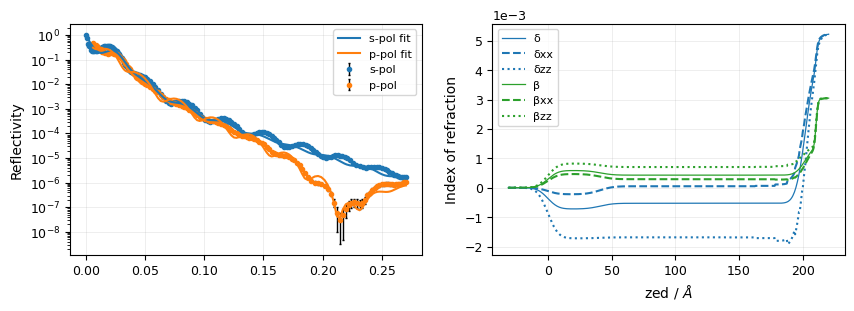

In [45]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10, 3))
fitter.objective.objectives[0].plot(ax=ax1, show_anisotropy=False)
fitter.objective.objectives[0].model.structure.plot(ax=ax2)
print(fitter.objective.varying_parameters())
save_fit_results_to_csv(fitter, filename="profile_fit_v5_mcmc.csv")

In [ ]:
objective.model.scale_p.setp(1, vary=True, bounds=(.5, 2))
objective.model.theta_offset_p.setp(0, vary=True, bounds=(-1, 1))
objective.model.scale_s.setp(1, vary=True, bounds=(.5, 2))
objective.model.theta_offset_s.setp(0, vary=True, bounds=(-1, 1))

def bkg_from_experiment(model, refl_data):
    p_pol = refl_data.p.y
    # locate the brewster angle region
    q_brewser_loc = np.argmin(p_pol)
    p_brewster = p_pol[q_brewser_loc-10:q_brewser_loc+10]
    model.bkg.setp(p_brewster.min(), vary=True, bounds=(0, p_brewster.max()))

bkg_from_experiment(objective.model, objective.data)
print(objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1          , bounds=[0.5, 2.0]>
<Parameter:   'scale_p'   , value=1          , bounds=[0.5, 2.0]>
<Parameter:     'bkg'     , value=3.1465e-08          , bounds=[0.0, 1.6757876143484724e-06]>
<Parameter:'theta_offset_s', value=0          , bounds=[-1.0, 1.0]>
<Parameter:'theta_offset_p', value=0          , bounds=[-1.0, 1.0]>
<Parameter:'Surface_283.7_thick', value=25.4729 +/- 1.64 , bounds=[0.0, 80.0]>
<Parameter:'Surface_283.7_rough', value=6.76272 +/- 0.497, bounds=[0.0, 20.0]>
<Parameter:'Surface_283.7_density', value=1.5 +/- 0.157, bounds=[1.5, 2.5]>
<Parameter:'Surface_283.7_rotation', value=0.825803 +/- 0.0305, bounds=[0.0, 1.5707963267948966]>
<Parameter: 'total_thick' , value=168.818 +/- 1.35 , bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=10 +/- 1.12 , bounds=[0.0, 10.0]>
<Parameter:   'density'   , value=1.62687 +/- 8.8

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.44848          , bounds=[0.5, 2.0]>
<Parameter:   'scale_p'   , value=0.933272          , bounds=[0.5, 2.0]>
<Parameter:     'bkg'     , value=0          , bounds=[0.0, 1.6757876143484724e-06]>
<Parameter:'theta_offset_s', value=0.11639          , bounds=[-1.0, 1.0]>
<Parameter:'theta_offset_p', value=0.341546          , bounds=[-1.0, 1.0]>
<Parameter:'Surface_283.7_thick', value=14.1221 +/- 1.64 , bounds=[0.0, 80.0]>
<Parameter:'Surface_283.7_rough', value=8.01858 +/- 0.497, bounds=[0.0, 20.0]>
<Parameter:'Surface_283.7_density', value=1.75396 +/- 0.157, bounds=[1.5, 2.5]>
<Parameter:'Surface_283.7_rotation', value=0.813887 +/- 0.0305, bounds=[0.0, 1.5707963267948966]>
<Parameter: 'total_thick' , value=176.761 +/- 1.35 , bounds=[160.0, 210.0]>
<Parameter:'surface_roughness', value=7.7506 +/- 1.12 , bounds=[0.0, 10.0]>
<Parameter:   'density' 

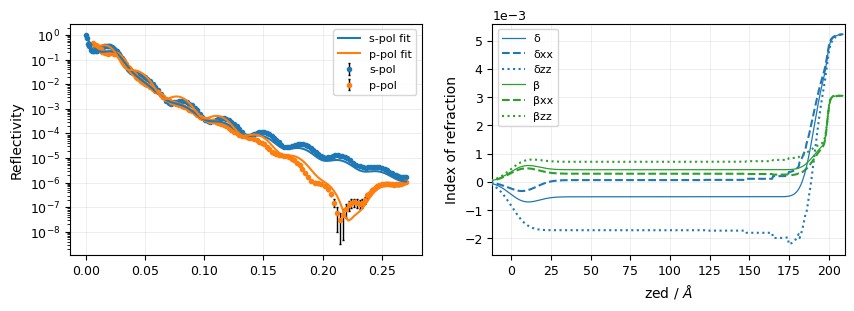

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10, 3))
fitter.objective.plot(ax=ax1, show_anisotropy=False)
fitter.objective.model.structure.plot(ax=ax2)
ax2.set_xlim(-12, 210)

print(fitter.objective.varying_parameters())

In [ ]:
print(f"Reduced chi2: {reduced_chi2(objective)}")

Reduced chi2: 38.83694094202528


In [ ]:
second_fitter = fit.CurveFitter(fitter.objective)
second_fitter.initialise("jitter")
samples = second_fitter.sample(100, skip_check=True)

100%|██████████| 100/100 [00:30<00:00,  3.28it/s]


In [ ]:
second_fitter.objective.corner()
plt.show()

ModuleNotFoundError: No module named 'corner'

In [ ]:
test_structure_dense = model_dense(test_energy, characteristic_thickness=8)

test_model_dense = fit.ReflectModel(test_structure_dense, energy=test_energy)

# test_model.scale_p.setp(1, vary=True, bounds=(1 / 10, 100))
# test_model.scale_p.setp(1, vary=True, bounds=(1 / 10, 100))
# test_model.theta_offset_p.setp(0, vary=True, bounds=(-2, 2))
# test_model.theta_offset_p.setp(0, vary=True, bounds=(-2, 2))

objective_dense = fit.AnisotropyObjective(
    test_model_dense,
    data["283.7"],
    logp_anisotropy_weight=0.5,
    transform=Transform("logY"),
)

select(objective_dense, "Oxide").thick.setp(vary=False)
select(objective_dense, "Oxide").rough.setp(vary=False)

select(objective_dense, "ZnPc").total_thick.setp(vary=True, bounds=(180, 210))
select(objective_dense, "ZnPc").surface_roughness.setp(vary=True, bounds=(0, 25))
# select(objective_dense, "ZnPc").density.setp(vary=True, bounds=(1.5, 1.7))
select(objective_dense, "ZnPc").characteristic_thickness.setp(
    value=8, vary=False, bounds=(3, 12)
)
select(objective_dense, "ZnPc").max_angle.setp(vary=True, bounds=(0, np.pi / 2))
select(objective_dense, "ZnPc").initial_angle.setp(vary=True, bounds=(0, np.pi / 2))

print(objective_dense.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter: 'total_thick' , value=200          , bounds=[180.0, 210.0]>
<Parameter:'surface_roughness', value=10          , bounds=[0.0, 25.0]>
<Parameter:  'max_angle'  , value=1.5708          , bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=0          , bounds=[0.0, 1.5707963267948966]>


In [ ]:
fitter_dense = fit.CurveFitter(objective_dense)
start_time = perf_counter()
fitter_dense.fit(method="differential_evolution", updating="deferred", workers=10)
elapsed_time_2 = perf_counter() - start_time
print(f"Fitting took {elapsed_time_2:.2f} seconds")

9.108250825074466: : 18it [02:16,  7.56s/it]


Fitting took 138.21 seconds


________________________________________________________________________________
Parameters:      None      
<Parameter: 'total_thick' , value=195.554 +/- 0.337, bounds=[180.0, 210.0]>
<Parameter:'surface_roughness', value=3.20399 +/- 0.453, bounds=[0.0, 25.0]>
<Parameter:   'density'   , value=1.66303 +/- 6.62e-15, bounds=[1.5, 1.7]>
<Parameter:'characteristic_thickness', value=19.674 +/- 1.59 , bounds=[1.0, 20.0]>
<Parameter:  'max_angle'  , value=0.712977 +/- 0.0326, bounds=[0.0, 1.5707963267948966]>
<Parameter:'initial_angle', value=0 +/- 0.0331, bounds=[0.0, 1.5707963267948966]>


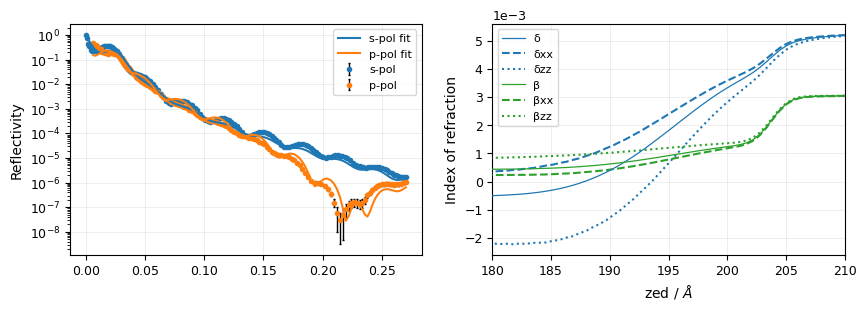

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10, 3))
fitter_dense.objective.plot(ax=ax1, show_anisotropy=False)
fitter_dense.objective.model.structure.plot(ax=ax2)
ax2.set_xlim(180, 210)

print(fitter_dense.objective.varying_parameters())

ImportError: cannot import name 'AdaptiveBookendedOrientationProfile' from 'utils.profile_slab' (/home/hduva/projects/xrr_notebooks/src/utils/profile_slab.py)

In [ ]:
import pandas as pd
from uncertainties import ufloat

from utils.helpers.fitting_helper import aic, bic, reduced_chi2

# Create dataframe for sparse model parameters
sparse_params = []
for p in fitter.objective.varying_parameters():
    sparse_params.append(
        {
            "name": p.name,
            "value": ufloat(p.value, p.stderr),
        }
    )
df_sparse = pd.DataFrame(sparse_params).set_index("name")

print("=" * 80)
print("Sparse Model Parameters")
print("=" * 80)
display(df_sparse)

# Create dataframe for dense model parameters
dense_params = []
for p in fitter_dense.objective.varying_parameters():
    dense_params.append(
        {
            "name": p.name,
            "value": ufloat(p.value, p.stderr),
        }
    )
df_dense = pd.DataFrame(dense_params).set_index("name")

print("=" * 80)
print("Dense Model Parameters")
print("=" * 80)
display(df_dense)

# Create dataframe for parameter differences
diff_data = []
for p, p_dense in zip(
    fitter.objective.varying_parameters(),
    fitter_dense.objective.varying_parameters(),
    strict=True,
):
    u_p = ufloat(p.value, p.stderr)
    u_p_dense = ufloat(p_dense.value, p_dense.stderr)
    delta = abs(u_p - u_p_dense)

    diff_data.append(
        {
            "name": p.name,
            "sparse_value": u_p,
            "dense_value": u_p_dense,
            "delta_abs": delta.nominal_value,
            "delta_sigma": delta.nominal_value / p.stderr if p.stderr else float("nan"),
        }
    )

df_diff = pd.DataFrame(diff_data).set_index("name")

print("=" * 80)
print("Parameter Differences")
print("=" * 80)
display(df_diff)

# Create dataframe for model statistics comparison
stats_comparison = pd.DataFrame(
    {
        "metric": ["reduced_chi2", "BIC", "AIC", "elapsed_time (s)"],
        "sparse": [
            reduced_chi2(fitter.objective),
            bic(fitter.objective),
            aic(fitter.objective),
            elapsed_time,
        ],
        "dense": [
            reduced_chi2(fitter_dense.objective),
            bic(fitter_dense.objective),
            aic(fitter_dense.objective),
            elapsed_time_2,
        ],
    }
).set_index("metric")

print("=" * 80)
print("Model Statistics Comparison")
print("=" * 80)
display(stats_comparison)

Sparse Model Parameters


,value
name,
total_thick,198.2+/-0.4
surface_roughness,2.8+/-0.6
max_angle,0.638+/-0.029
initial_angle,0.000+/-0.028


Dense Model Parameters


,value
name,
total_thick,198.0+/-0.4
surface_roughness,2.8+/-0.6
max_angle,0.641+/-0.027
initial_angle,0.000+/-0.026


Parameter Differences


/tmp/ipykernel_3770975/2586526993.py:47: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  delta = abs(u_p - u_p_dense)


,sparse_value,dense_value,delta_abs,delta_sigma
name,,,,
total_thick,198.2+/-0.4,198.0+/-0.4,0.126687,0.338806
surface_roughness,2.8+/-0.6,2.8+/-0.6,0.025134,0.043825
max_angle,0.638+/-0.029,0.641+/-0.027,0.003272,0.113402
initial_angle,0.000+/-0.028,0.000+/-0.026,0.000000,0.000000


Model Statistics Comparison


,sparse,dense
metric,,
reduced_chi2,41.673539,41.503490
BIC,12191.434755,12141.780504
AIC,12176.673317,12127.019066
elapsed_time (s),11.694028,138.211712


In [ ]:
# Determine how much faster elapsed_time is to elapsed_time_2
print(f"Sparse model is {elapsed_time_2 / elapsed_time:.2f}x faster than dense model")


Sparse model is 11.82x faster than dense model
